# Resultados Combinados — Figuras para o Artigo

Este notebook carrega os perfis de potência residual (3 alemães + 1 brasileiro),
executa o MLBatLife para cada um, e gera as figuras e tabelas finais para o artigo.

**Pré-requisito:** executar `Notebook_Perfis_OPSD.ipynb` e `Notebook_Perfil_Brasil.ipynb`
antes deste notebook para garantir que os CSVs de perfil existam.

In [9]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

BASE_DIR = (
    Path(__file__).resolve().parent.parent.parent
    if "__file__" in dir()
    else Path.cwd().resolve().parent.parent
)
MLBAT_DIR = (BASE_DIR / "code" / "model").resolve()
OUT_DIR   = BASE_DIR / "code" / "data" /  "pic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(MLBAT_DIR) not in sys.path:
    sys.path.insert(0, str(MLBAT_DIR))

os.chdir(MLBAT_DIR)
import MLBatLife_Pred as blp

plt.rcParams.update({"figure.dpi": 120})

STRATEGY = 0
QNOM     = 5

# Limiares de classificação
SOH_SAUDAVEL = 0.90
SOH_ATENCAO  = 0.80

# Dias iniciais excluídos da regressão (break-in)
BREAK_IN = 30

# Perfis: alias → {path, carga}
PROFILES = {
    "Residencial Alemão A": {
        "path": BASE_DIR / "code" / "data" / "opsd" / "profile_residential3.csv",
        "carga": "consumo padrão",
    },
    "Residencial Alemão B": {
        "path": BASE_DIR / "code" / "data" / "opsd" / "profile_residential4.csv",
        "carga": "bomba de calor + veículo elétrico",
    },
    "Residencial Alemão C": {
        "path": BASE_DIR / "code" / "data" / "opsd" / "profile_residential6.csv",
        "carga": "perfil alternativo",
    },
    "Residencial Brasil": {
        "path": BASE_DIR / "code" / "data" / "brasil" / "profile_brasil_vitoria.csv",
        "carga": "5 kWp, 200 kWh/mês",
    },
}
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

print(f"BASE_DIR: {BASE_DIR}")

BASE_DIR: C:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso


In [10]:
# 1) Carregar perfis e executar MLBatLife
results = {}
for name, pinfo in PROFILES.items():
    df = pd.read_csv(pinfo["path"])
    m_time   = df["Time"].values
    inp_prof = df["Power"].values

    features, day = blp.extract_features(m_time, inp_prof)
    soh_hat       = blp.estimate_soh(features, day, STRATEGY, QNOM)

    results[name] = {
        "df":       df,
        "day":      day,
        "soh":      soh_hat,
        "features": features,
        "n_days":   len(day),
    }
    print(f"{name}: {len(day)} dias | SOH final = {soh_hat[-1]:.4f}")

Residencial Alemão A: 495 dias | SOH final = 0.9279
Residencial Alemão B: 847 dias | SOH final = 0.8956
Residencial Alemão C: 694 dias | SOH final = 0.9216
Residencial Brasil: 1825 dias | SOH final = 0.8055


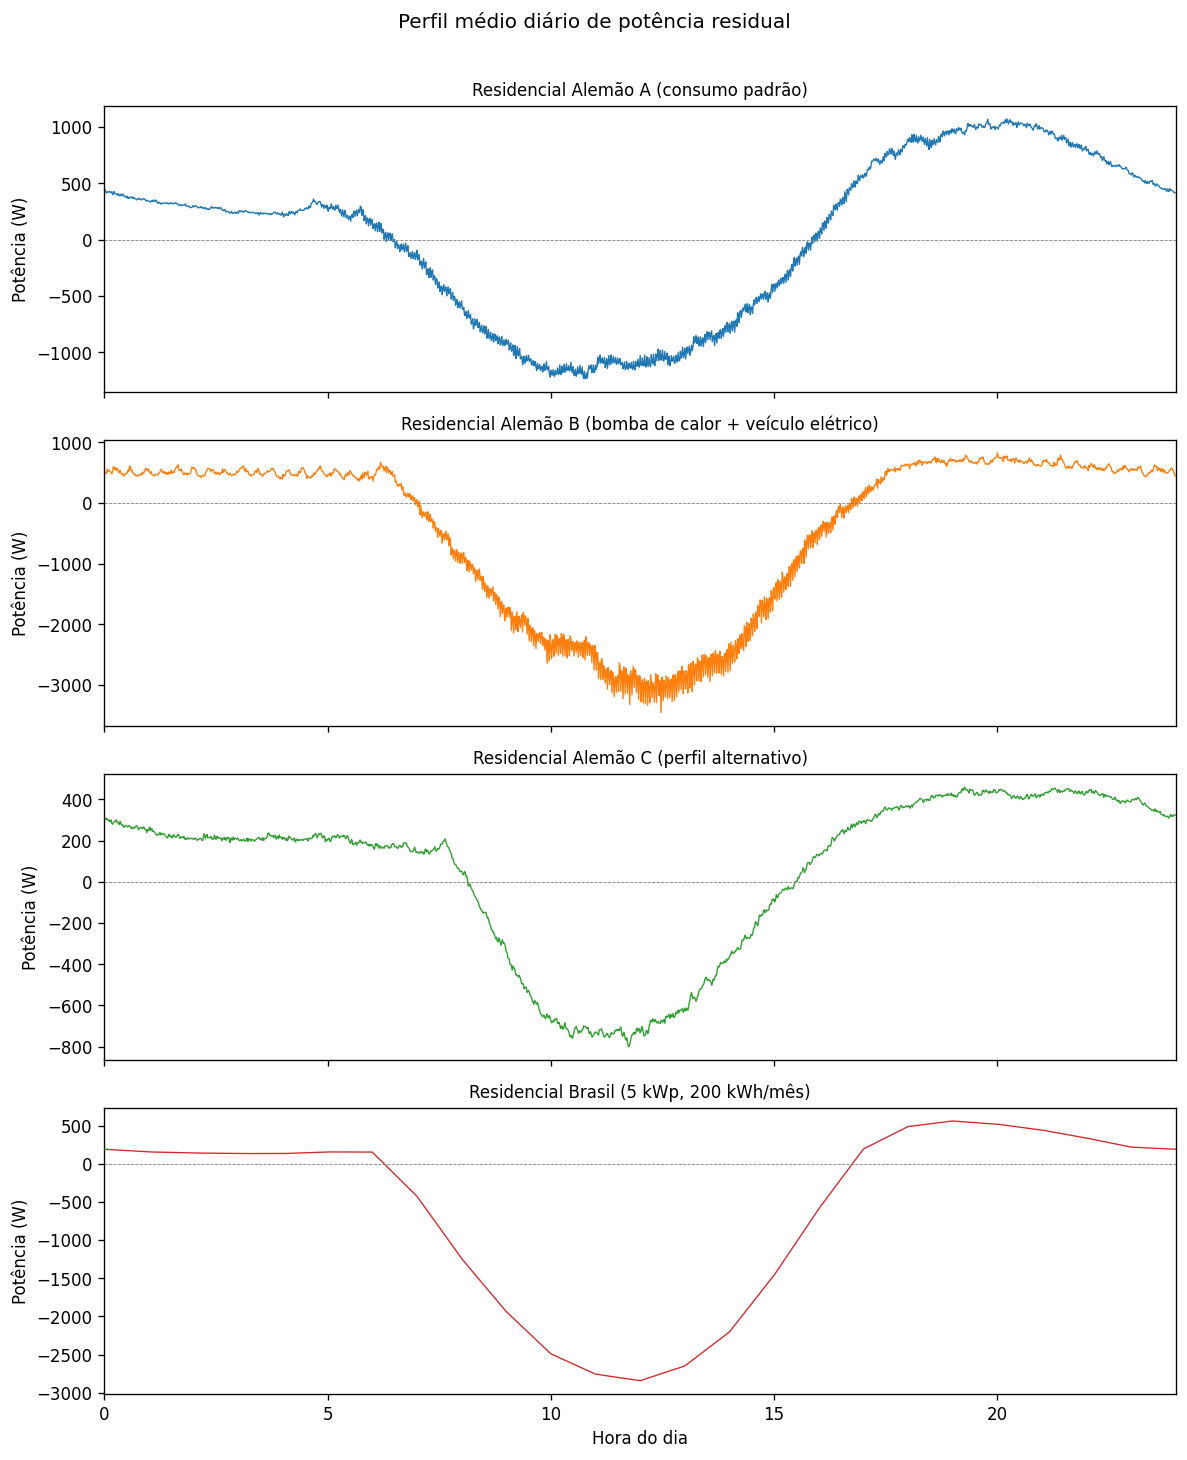

In [11]:
# 2) Perfis médios diários de potência residual (4 subplots)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
hours = np.arange(1440) / 60.0

for ax, (name, res), color in zip(axes, results.items(), COLORS):
    power = res["df"]["Power"].values
    n_full = (len(power) // 1440) * 1440
    daily_matrix = power[:n_full].reshape(-1, 1440)
    avg_day = daily_matrix.mean(axis=0)
    ax.plot(hours, avg_day, color=color, linewidth=0.8)
    ax.set_ylabel("Potência (W)")
    ax.set_title(f"{name} ({PROFILES[name]['carga']})", fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Hora do dia")
axes[-1].set_xlim(0, 24)
fig.suptitle("Perfil médio diário de potência residual", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "combined_profiles_avg_day.png", dpi=300, bbox_inches="tight")
plt.show()

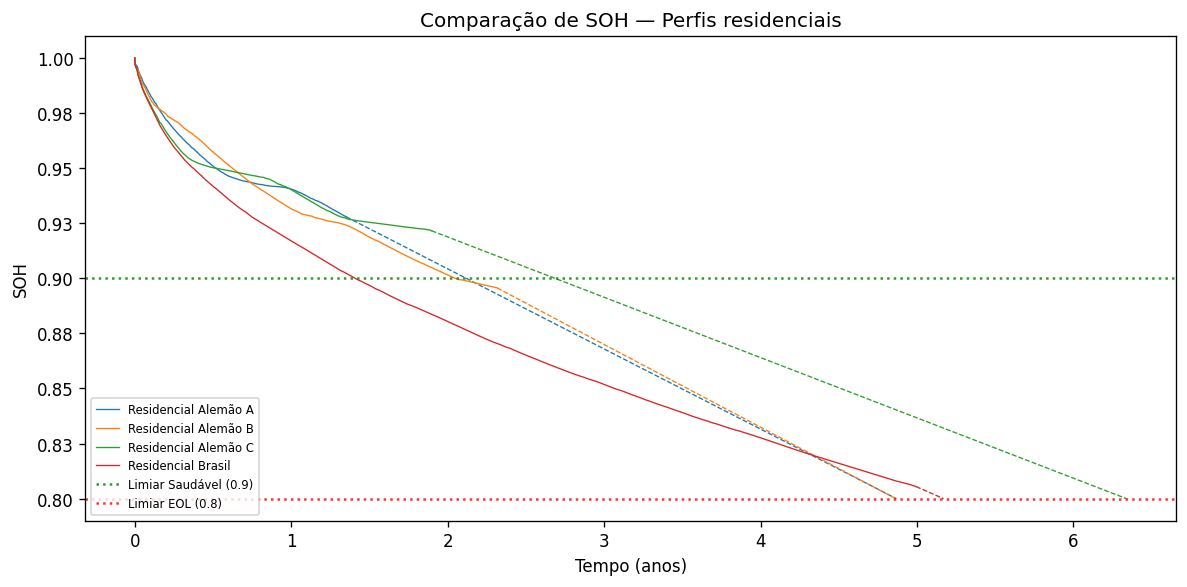

In [12]:
# 3) SOH ao longo do tempo — 4 curvas + extrapolação até EOL + limiares
fig, ax = plt.subplots(figsize=(10, 5))

for (name, res), color in zip(results.items(), COLORS):
    soh = res["soh"]
    day = res["day"]
    years = day / 365.25
    ax.plot(years, soh, color=color, linewidth=0.8, label=name)

    # Extrapolação até EOL: slope da regressão (curva completa s/ break-in),
    # ancorada no último SOH observado para continuidade visual.
    if soh[-1] >= SOH_ATENCAO:
        mask = day >= BREAK_IN
        slope, _intercept = np.polyfit(day[mask], soh[mask], 1)
        if slope < 0:
            eol_day = day[-1] + (SOH_ATENCAO - soh[-1]) / slope
            ext_days = np.array([day[-1], eol_day])
            ext_soh  = soh[-1] + slope * (ext_days - day[-1])
            ax.plot(ext_days / 365.25, ext_soh, color=color, linewidth=0.8, linestyle="--")

ax.axhline(SOH_SAUDAVEL, color="green", linewidth=1.5, linestyle=":",
           alpha=0.8, label=f"Limiar Saudável ({SOH_SAUDAVEL})")
ax.axhline(SOH_ATENCAO, color="red", linewidth=1.5, linestyle=":",
           alpha=0.8, label=f"Limiar EOL ({SOH_ATENCAO})")

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlabel("Tempo (anos)")
ax.set_ylabel("SOH")
ax.set_title("Comparação de SOH — Perfis residenciais")
ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.savefig(OUT_DIR / "combined_soh_comparison.png", dpi=300)
plt.show()

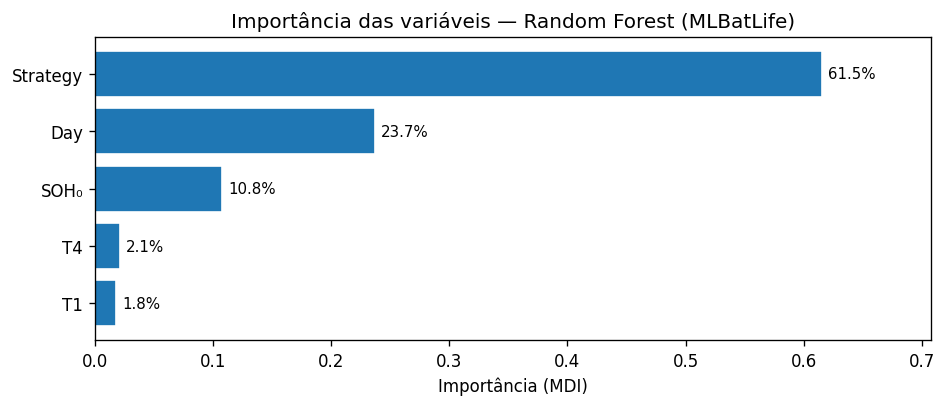


Modelo: RandomForestRegressor (n_estimators=50, max_depth=30)


,Feature,Importância,Importância (%)
0,Strategy,0.615427,61.5%
1,Day,0.237250,23.7%
2,SOH₀,0.108010,10.8%
3,T4,0.021400,2.1%
4,T1,0.017912,1.8%


In [13]:
# 4) Feature importance do modelo Random Forest (MLBatLife)
#
# O modelo é um RandomForestRegressor pré-treinado (n_estimators=50,
# max_depth=30). A importância de cada feature é calculada pela
# diminuição média de impureza (MDI) nas árvores do ensemble.
import pickle

model_path = MLBAT_DIR / "MLBatLife_Model.pkl"
with open(model_path, "rb") as f:
    model_data = pickle.load(f)

rf_model = model_data[0]  # RandomForestRegressor

feature_names = ["Day", "SOH₀", "T1", "T4", "Strategy"]
importances = rf_model.feature_importances_

# Tabela de importância
fi_df = pd.DataFrame({
    "Feature":      feature_names,
    "Importância":  importances,
    "Importância (%)": [f"{v*100:.1f}%" for v in importances],
}).sort_values("Importância", ascending=False).reset_index(drop=True)

# Gráfico de barras horizontais
fig, ax = plt.subplots(figsize=(8, 3.5))
sorted_idx = importances.argsort()
ax.barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[COLORS[0]] * len(sorted_idx),
    edgecolor="white",
)
for i, idx in enumerate(sorted_idx):
    ax.text(importances[idx] + 0.005, i, f"{importances[idx]*100:.1f}%",
            va="center", fontsize=9)
ax.set_xlabel("Importância (MDI)")
ax.set_title("Importância das variáveis — Random Forest (MLBatLife)")
ax.set_xlim(0, max(importances) * 1.15)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", dpi=300)
plt.show()

print(f"\nModelo: {type(rf_model).__name__} "
      f"(n_estimators={rf_model.n_estimators}, max_depth={rf_model.max_depth})")
fi_df

In [14]:
# 5) Tabela comparativa: SOH@1ano, SOH final, classificação, EOL
rows = []
for name, res in results.items():
    soh = res["soh"]
    day = res["day"]
    soh_final = float(soh[-1])

    # SOH@1 ano
    mask_1y = day <= 365
    soh_1ano = float(soh[mask_1y][-1]) if mask_1y.any() else None

    # Classificação final
    if soh_final >= SOH_SAUDAVEL:
        classif = "Saudável"
    elif soh_final >= SOH_ATENCAO:
        classif = "Atenção"
    else:
        classif = "Fim de vida"

    # EOL estimado — slope da regressão (curva completa s/ break-in),
    # projetado a partir do último SOH observado
    eol_reached = soh < SOH_ATENCAO
    if eol_reached.any():
        eol_day = float(day[eol_reached][0])
    else:
        mask = day >= BREAK_IN
        slope, _intercept = np.polyfit(day[mask], soh[mask], 1)
        if slope < 0:
            eol_day = day[-1] + (SOH_ATENCAO - soh[-1]) / slope
        else:
            eol_day = None

    eol_anos = round(eol_day / 365.25, 1) if eol_day else "—"

    rows.append({
        "Perfil":          name,
        "Período (dias)":  len(day),
        "SOH@1 ano":       round(soh_1ano, 4) if soh_1ano else "—",
        "SOH final":       round(soh_final, 4),
        "Classificação":   classif,
        "EOL est. (anos)": eol_anos,
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "combined_soh_summary.csv", index=False)
print(f"Tabela salva em {OUT_DIR / 'combined_soh_summary.csv'}")
summary

Tabela salva em C:\Users\vdmas\OneDrive\FAESA\Trabalho de Conclusao de Curso\code\data\pic\combined_soh_summary.csv


,Perfil,Período (dias),SOH@1 ano,SOH final,Classificação,EOL est. (anos)
0,Residencial Alemão A,495,0.9405,0.9279,Saudável,4.9
1,Residencial Alemão B,847,0.9316,0.8956,Atenção,4.9
2,Residencial Alemão C,694,0.9403,0.9216,Saudável,6.3
3,Residencial Brasil,1825,0.9169,0.8055,Atenção,5.2
